## You Shall Not sPam(YSNP)
### Esteira ML Detecção de Spam
#### Trocadalho com o famoso termo da franquia Lord of Rings: You Shall Not Pass!

In [20]:
#Instalação de dependência faltante
!pip install seaborn

In [8]:
# Célula 1: Importação das Bibliotecas Necessárias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [9]:
# Célula 2: Carregamento do Conjunto de Dados diretamente da URL da UCI
import io
import zipfile
import requests

# URL direta fornecida pelo repositório UCI
url = "https://archive.ics.uci.edu/static/public/94/spambase.zip"

# Definindo os nomes das colunas com base na documentação do Spambase
colunas = [
    f'word_freq_{i}' for i in range(48)
] + [
    f'char_freq_{i}' for i in range(6)
] + [
    'capital_run_length_average', 
    'capital_run_length_longest', 
    'capital_run_length_total', 
    'is_spam'
]

print("Baixando os dados diretamente da UCI...")
# Fazendo a requisição HTTP para obter o arquivo ZIP da web
response = requests.get(url)

# Lendo o arquivo ZIP diretamente da memória e extraindo o 'spambase.data'
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('spambase.data') as f:
        df = pd.read_csv(f, header=None, names=colunas)

print(f"Download concluído! Dimensões do dataset: {df.shape}")
df.head()

Baixando os dados diretamente da UCI...
Download concluído! Dimensões do dataset: (4601, 58)


,word_freq_0,word_freq_1,word_freq_2,word_freq_3,word_freq_4,word_freq_5,word_freq_6,word_freq_7,word_freq_8,word_freq_9,...,char_freq_0,char_freq_1,char_freq_2,char_freq_3,char_freq_4,char_freq_5,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [10]:
# Célula 3: Requisito 3 - Estatísticas Descritivas Gerais
print("--- Informações Gerais do Dataset ---")
print(df.info())

print("\n--- Estatísticas Descritivas ---")
# Exibe a transposta para facilitar a leitura de muitas colunas
df.describe().T.head(10)

--- Informações Gerais do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_0                 4601 non-null   float64
 1   word_freq_1                 4601 non-null   float64
 2   word_freq_2                 4601 non-null   float64
 3   word_freq_3                 4601 non-null   float64
 4   word_freq_4                 4601 non-null   float64
 5   word_freq_5                 4601 non-null   float64
 6   word_freq_6                 4601 non-null   float64
 7   word_freq_7                 4601 non-null   float64
 8   word_freq_8                 4601 non-null   float64
 9   word_freq_9                 4601 non-null   float64
 10  word_freq_10                4601 non-null   float64
 11  word_freq_11                4601 non-null   float64
 12  word_freq_12                4601 non-null   float64


,count,mean,std,min,25%,50%,75%,max
word_freq_0,4601.0,0.104553,0.305358,0.0,0.0,0.0,0.00,4.54
word_freq_1,4601.0,0.213015,1.290575,0.0,0.0,0.0,0.00,14.28
word_freq_2,4601.0,0.280656,0.504143,0.0,0.0,0.0,0.42,5.10
word_freq_3,4601.0,0.065425,1.395151,0.0,0.0,0.0,0.00,42.81
word_freq_4,4601.0,0.312223,0.672513,0.0,0.0,0.0,0.38,10.00
word_freq_5,4601.0,0.095901,0.273824,0.0,0.0,0.0,0.00,5.88
word_freq_6,4601.0,0.114208,0.391441,0.0,0.0,0.0,0.00,7.27
word_freq_7,4601.0,0.105295,0.401071,0.0,0.0,0.0,0.00,11.11
word_freq_8,4601.0,0.090067,0.278616,0.0,0.0,0.0,0.00,5.26
word_freq_9,4601.0,0.239413,0.644755,0.0,0.0,0.0,0.16,18.18


In [11]:
# Célula 4: Requisito 4 - Transformação em Colunas
# Normalizando os atributos preditores numéricos para a mesma escala (Média=0, Variância=1)
# Isso otimiza o desempenho de diversos algoritmos de Machine Learning.

X_raw = df.drop(columns=['is_spam'])
y_raw = df['is_spam']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)

# Recriando o dataframe transformado
df_transformado = X_scaled.copy()
df_transformado['is_spam'] = y_raw.values

print("Colunas numéricas normalizadas com StandardScaler.")
df_transformado.head()

Colunas numéricas normalizadas com StandardScaler.


,word_freq_0,word_freq_1,word_freq_2,word_freq_3,word_freq_4,word_freq_5,word_freq_6,word_freq_7,word_freq_8,word_freq_9,...,char_freq_0,char_freq_1,char_freq_2,char_freq_3,char_freq_4,char_freq_5,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,-0.342434,0.330885,0.712859,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.158453,-0.514307,-0.155198,0.624007,-0.308355,-0.103048,-0.045247,0.045298,-0.008724,1
1,0.345359,0.051909,0.435130,-0.0469,-0.256117,0.672399,0.244743,-0.088010,-0.323302,1.086711,...,-0.158453,-0.026007,-0.155198,0.126203,0.423783,0.008763,-0.002443,0.250563,1.228324,1
2,-0.145921,-0.165072,0.851723,-0.0469,1.364846,0.343685,0.193644,0.036670,1.974017,0.016422,...,-0.117376,0.014684,-0.155198,0.008496,0.440053,-0.079754,0.145921,2.221106,3.258733,1
3,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.158453,-0.007511,-0.155198,-0.161934,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222,1
4,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.158453,-0.014910,-0.155198,-0.164387,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222,1


In [12]:
# Célula 5: Requisito 5 - Transformação em Linhas
# Remoção de linhas duplicadas no dataset para evitar vazamento de dados e overfitting.

linhas_antes = df_transformado.shape[0]
df_transformado = df_transformado.drop_duplicates().reset_index(drop=True)
linhas_depois = df_transformado.shape[0]

print(f"Linhas antes da transformação: {linhas_antes}")
print(f"Linhas após a remoção de duplicatas (transformação de linhas): {linhas_depois}")
print(f"Total de {linhas_antes - linhas_depois} linhas duplicadas removidas.")

Linhas antes da transformação: 4601
Linhas após a remoção de duplicatas (transformação de linhas): 4210
Total de 391 linhas duplicadas removidas.


In [13]:
# Célula 6: Requisito 6 - Criação de Três Subconjuntos (Treino, Validação e Teste)
# Separação dos atributos (X) e do alvo (y)
X = df_transformado.drop(columns=['is_spam'])
y = df_transformado['is_spam']

# 1º Passo: Separar Treino (70%) e o restante (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# 2º Passo: Dividir o restante igualmente entre Validação (15%) e Teste (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Tamanho do Conjunto de Treino: {X_train.shape[0]} amostras (70%)")
print(f"Tamanho do Conjunto de Validação: {X_val.shape[0]} amostras (15%)")
print(f"Tamanho do Conjunto de Teste: {X_test.shape[0]} amostras (15%)")

Tamanho do Conjunto de Treino: 2947 amostras (70%)
Tamanho do Conjunto de Validação: 631 amostras (15%)
Tamanho do Conjunto de Teste: 632 amostras (15%)


In [14]:
# Célula 7: Requisito 7 - Treinamento e Avaliação do Modelo
# Instanciando o classificador Random Forest
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinamento com as amostras de Treino
modelo.fit(X_train, y_train)

# Validação do modelo com o conjunto de Validação (Ajuste fino se necessário)
preds_val = modelo.predict(X_val)
acc_val = accuracy_score(y_val, preds_val)
print(f"Acurácia obtida no conjunto de Validação: {acc_val:.4f}")

# Avaliação final com o conjunto de Teste (Dados nunca vistos pelo modelo)
preds_teste = modelo.predict(X_test)

Acurácia obtida no conjunto de Validação: 0.9445


Acurácia Final do Modelo (Conjunto de Teste): 92.56%

Matriz de Confusão:
[[363  17]
 [ 30 222]]


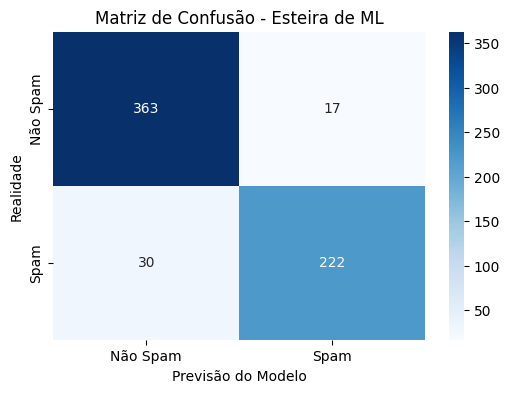


Relatório de Classificação Completo:
              precision    recall  f1-score   support

    Não Spam       0.92      0.96      0.94       380
        Spam       0.93      0.88      0.90       252

    accuracy                           0.93       632
   macro avg       0.93      0.92      0.92       632
weighted avg       0.93      0.93      0.93       632



In [15]:
# Célula 8: Requisito 8 - Matriz de Confusão e Acurácia (Dados de Teste)
acuracia_final = accuracy_score(y_test, preds_teste)
matriz_conf = confusion_matrix(y_test, preds_teste)

print(f"Acurácia Final do Modelo (Conjunto de Teste): {acuracia_final * 100:.2f}%\n")
print("Matriz de Confusão:")
print(matriz_conf)

# Plotando de forma visual para enriquecer o trabalho
plt.figure(figsize=(6,4))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Não Spam', 'Spam'], yticklabels=['Não Spam', 'Spam'])
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.title('Matriz de Confusão - Esteira de ML')
plt.show()

print("\nRelatório de Classificação Completo:")
print(classification_report(y_test, preds_teste, target_names=['Não Spam', 'Spam']))

In [18]:
# Célula 9: Requisito 9 - Resultado de uma Predição do Modelo Implantado
# Simulando a chegada de um novo e-mail (pegando uma linha real do conjunto de teste para teste)
exemplo_email = X_test.iloc[[10]] 
classe_real = y_test.iloc[10]

# Realizando a predição isolada
predicao_isolada = modelo.predict(exemplo_email)[0]
probabilidades = modelo.predict_proba(exemplo_email)[0]

print("--- Executando Predição Unitária ---")
print(f"E-mail indexado analisado pelo sistema.")
print(f"Probabilidade de NÃO ser Spam: {probabilidades[0]*100:.2f}%")
print(f"Probabilidade de SER Spam: {probabilidades[1]*100:.2f}%")
print(f"Resultado da classificação da IA: {'SPAM' if predicao_isolada == 1 else 'E-MAIL CONFIÁVEL'}")
print(f"Gabarito real (Validação Humana): {'SPAM' if classe_real == 1 else 'E-MAIL CONFIÁVEL'}")

--- Executando Predição Unitária ---
E-mail indexado analisado pelo sistema.
Probabilidade de NÃO ser Spam: 29.00%
Probabilidade de SER Spam: 71.00%
Resultado da classificação da IA: SPAM
Gabarito real (Validação Humana): SPAM
